In [3]:
import sys
print(sys.executable)


E:\SafeCityAi\modelService\venv\Scripts\python.exe


In [4]:
import os
import sys
import numpy as np
import random
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity


In [5]:
PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)
print(PROJECT_ROOT)

E:\SafeCityAi\modelService


In [6]:
from recognizer.embedding_generator import EmbeddingGenerator

generator = EmbeddingGenerator()


In [7]:
DATASET_ROOT = r"../dataset/cufs"
PHOTO_DIR = os.path.join(DATASET_ROOT, "photos")
SKETCH_DIR = os.path.join(DATASET_ROOT, "sketches")

assert os.path.exists(PHOTO_DIR)
assert os.path.exists(SKETCH_DIR)


In [8]:
import os

print(os.path.exists(PHOTO_DIR), PHOTO_DIR)
print(os.path.exists(SKETCH_DIR), SKETCH_DIR)

print("Photos:", len(os.listdir(PHOTO_DIR)))
print("Sketches:", len(os.listdir(SKETCH_DIR)))


True ../dataset/cufs\photos
True ../dataset/cufs\sketches
Photos: 188
Sketches: 188


In [11]:
print("Photos:")
for f in sorted(photo_files)[:10]:
    print(f)

print("\nSketches:")
for f in sorted(sketch_files)[:10]:
    print(f)


Photos:
f-005-01.jpg
f-006-01.jpg
f-007-01.jpg
f-008-01.jpg
f-009-01.jpg
f-010-01.jpg
f-011-01.jpg
f-012-01.jpg
f-013-01.jpg
f-014-01.jpg

Sketches:
F2-005-01-sz1.jpg
F2-006-01-sz1.jpg
F2-007-01-sz1.jpg
F2-008-01-sz1.jpg
F2-009-01-sz1.jpg
F2-010-01-sz1.jpg
F2-011-01-sz1.jpg
F2-012-01-sz1.jpg
F2-013-01-sz1.jpg
F2-014-01-sz1.jpg


In [15]:
import re

def photo_id(filename):
    # f-005-01.jpg → 005-01
    m = re.search(r"(\d{3}-\d{2})", filename)
    return m.group(1) if m else None

def sketch_id(filename):
    # F2-005-01-sz1.jpg → 005-01
    m = re.search(r"(\d{3}-\d{2})", filename)
    return m.group(1) if m else None


In [13]:
photo_map = {}
for f in photo_files:
    pid = photo_id(f)
    if pid:
        photo_map[pid] = f

sketch_map = {}
for f in sketch_files:
    sid = sketch_id(f)
    if sid:
        sketch_map[sid] = f

common_ids = sorted(set(photo_map) & set(sketch_map))

print("Paired identities:", len(common_ids))
print("Photo only:", len(photo_map) - len(common_ids))
print("Sketch only:", len(sketch_map) - len(common_ids))


Paired identities: 101
Photo only: 0
Sketch only: 0


In [16]:
photo_files = sorted(os.listdir(PHOTO_DIR))
sketch_files = sorted(os.listdir(SKETCH_DIR))

photo_map = {}
for f in photo_files:
    pid = photo_id(f)
    if pid:
        photo_map[pid] = f

sketch_map = {}
for f in sketch_files:
    sid = sketch_id(f)
    if sid:
        sketch_map[sid] = f

common_ids = sorted(set(photo_map) & set(sketch_map))

pairs = [
    {
        "id": pid,
        "photo_path": os.path.join(PHOTO_DIR, photo_map[pid]),
        "sketch_path": os.path.join(SKETCH_DIR, sketch_map[pid])
    }
    for pid in common_ids
]

print("Paired identities:", len(pairs))


Paired identities: 101


In [17]:
photo_db = []

for p in pairs:
    img = Image.open(p["photo_path"])
    emb = generator.photo_to_embedding(img)
    if emb is None:
        continue

    photo_db.append({
        "id": p["id"],
        "photo_path": p["photo_path"],
        "embedding": emb
    })

print("Photo embeddings:", len(photo_db))


Photo embeddings: 101


In [19]:
import random
from PIL import Image

query = random.choice(pairs)

query_img = Image.open(query["sketch_path"])
query_emb = generator.sketch_to_embedding(query_img)

query["id"], query_emb.shape


('008-01', (512,))

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

results = []

for entry in photo_db:
    score = cosine_similarity(
        query_emb.reshape(1, -1),
        entry["embedding"].reshape(1, -1)
    )[0][0]

    results.append({
        "id": entry["id"],
        "photo_path": entry["photo_path"],
        "score": score
    })

results = sorted(results, key=lambda x: x["score"], reverse=True)
top5 = results[:5]

top5


[{'id': '008-01',
  'photo_path': '../dataset/cufs\\photos\\m1-008-01.jpg',
  'score': np.float32(0.5718484)},
 {'id': '084-01',
  'photo_path': '../dataset/cufs\\photos\\m-084-01.jpg',
  'score': np.float32(0.543118)},
 {'id': '046-01',
  'photo_path': '../dataset/cufs\\photos\\m-046-01.jpg',
  'score': np.float32(0.5202493)},
 {'id': '010-01',
  'photo_path': '../dataset/cufs\\photos\\m1-010-01.jpg',
  'score': np.float32(0.50544286)},
 {'id': '012-01',
  'photo_path': '../dataset/cufs\\photos\\m1-012-01.jpg',
  'score': np.float32(0.48510274)}]

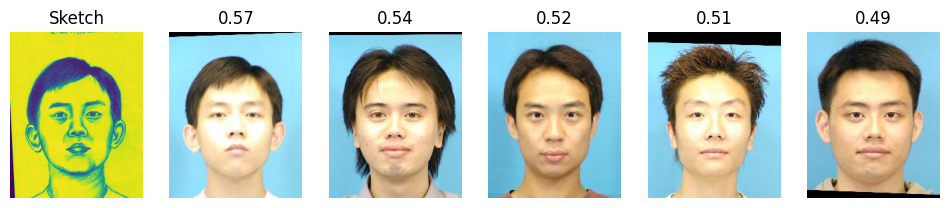

In [21]:
import matplotlib.pyplot as plt

def show_results(query, results):
    plt.figure(figsize=(12, 3))

    # Query sketch
    plt.subplot(1, 6, 1)
    plt.imshow(Image.open(query["sketch_path"]))
    plt.title("Sketch")
    plt.axis("off")

    for i, r in enumerate(results):
        plt.subplot(1, 6, i + 2)
        plt.imshow(Image.open(r["photo_path"]))
        plt.title(f"{r['score']:.2f}")
        plt.axis("off")

    plt.show()

show_results(query, top5)
